# PNPedia interface

This notebook demonstrates how to use `PyART.analytic.pnpedia.PNPedia` to load a PN quantity from the local PNPedia repository and plot it as a function of PN parameter `x`.

Quantity: `energy_circular_nonspinning_binding` (nonspinning, circular, non-tidal, binding energy).

The `get_pn_quantity()` call returns a callable and the symbolic argument order.

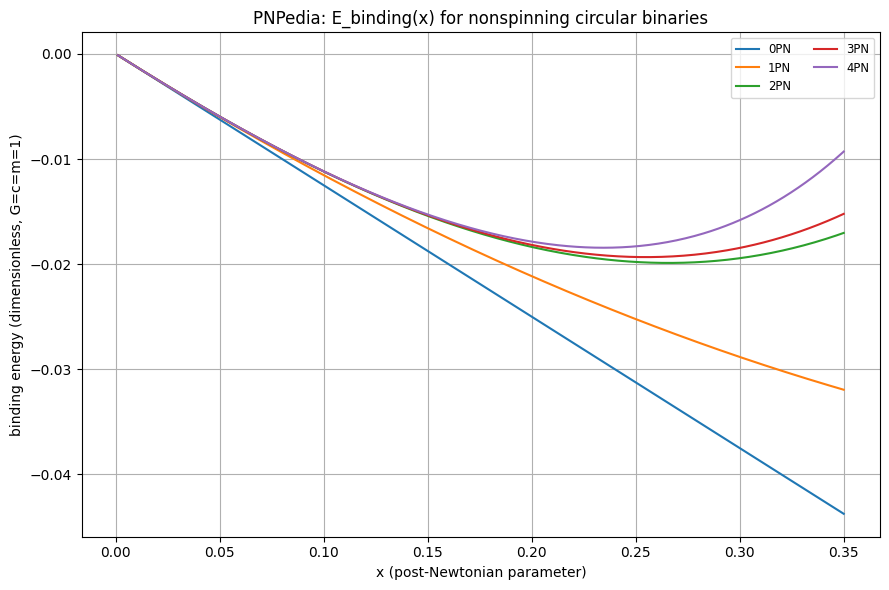

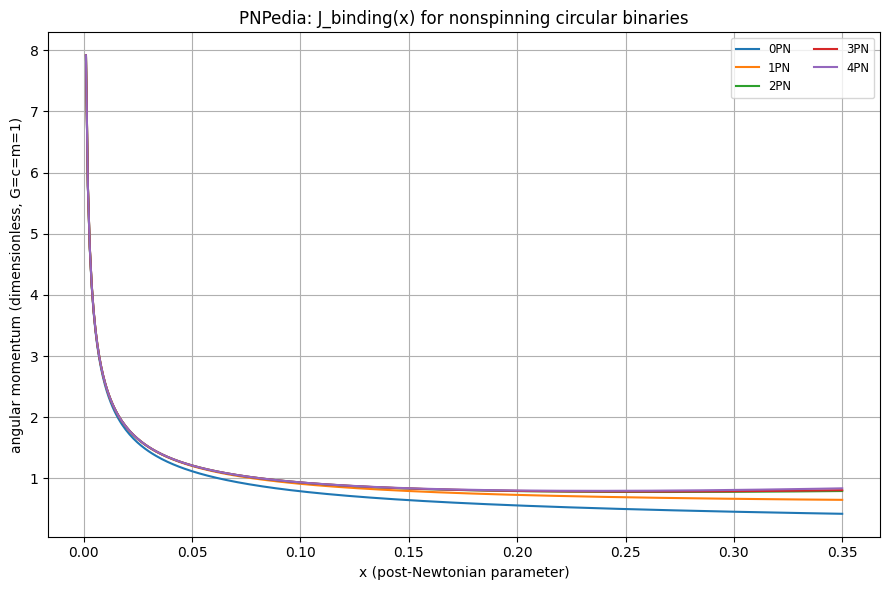

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PyART.analytic.pnpedia import PNPedia

# Path to the local PNPedia repository clone (in this repo tree)
pnpedia_path = './PNPedia'
npd = PNPedia(path=pnpedia_path, dowload=True)

# PN variable x range for circular inspiral (small x region)
x = np.linspace(0.001, 0.35, 400)

# Evaluate with geometric-like normalized constants, and symmetric mass ratio nu=0.25
# (set G,c,m,b0=1 for demonstration, then tune for physics units as required).
G = np.ones_like(x)
b0 = np.ones_like(x)
c = np.ones_like(x)
m = np.ones_like(x)
nu = 0.25 * np.ones_like(x)

energy_orders = ['0', '1', '2', '3', '4']
JM_orders = ['0', '1', '2', '3', '4']

# 1) Plot E(x) for multiple PN truncations
plt.figure(figsize=(9,6))
for order in energy_orders:
    analyticf, vrs = npd.get_pn_quantity('energy_circular_nonspinning_binding', order).to_function()
    value_map = {'G': 1.0, 'b0': 1.0, 'c': 1.0, 'm': 1.0, 'nu': 0.25, 'x': x}
    args = [value_map[str(s)] for s in vrs]
    energy = analyticf(*args)
    plt.plot(x, energy, lw=1.5, label=f'{order}PN')

plt.xlabel('x (post-Newtonian parameter)')
plt.ylabel('binding energy (dimensionless, G=c=m=1)')
plt.title('PNPedia: E_binding(x) for nonspinning circular binaries')
plt.grid(True)
plt.legend(ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

# 2) Plot J(x) for multiple PN truncations
plt.figure(figsize=(9,6))
for order in JM_orders:
    analyticf, vrs = npd.get_pn_quantity('angular_momentum_circular_nonspinning_conservative', order).to_function()
    value_map = {'G': 1.0, 'b0': 1.0, 'c': 1.0, 'm': 1.0, 'nu': 0.25, 'x': x}
    args = [value_map[str(s)] for s in vrs]
    angmom = analyticf(*args)
    plt.plot(x, angmom, lw=1.5, label=f'{order}PN')

plt.xlabel('x (post-Newtonian parameter)')
plt.ylabel('angular momentum (dimensionless, G=c=m=1)')
plt.title('PNPedia: J_binding(x) for nonspinning circular binaries')
plt.grid(True)
plt.legend(ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

## Compare the analytical PN binding energy to a NR curve

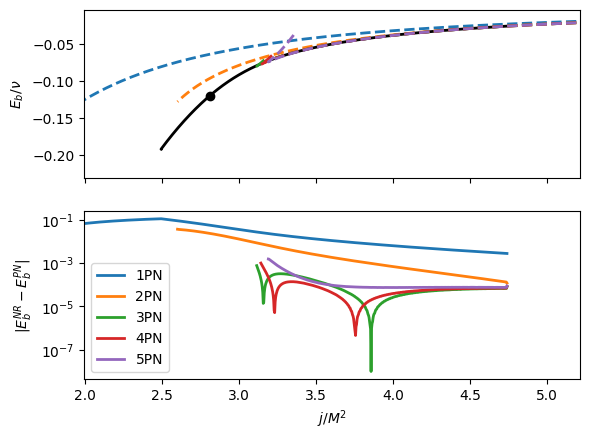

In [ ]:
# binding energy vs angular momentum plot, compare with NR
# Note: this NR comparison is rather "naive", one should in principle shift the NR curve
# such that the final state (remnant) coincides with the last point of the NR curve, see
# the appendix of https://arxiv.org/pdf/1506.08457


# NR curve from SXS catalog
from PyART.catalogs import sxs
sxs_waveform = sxs.Waveform_SXS(ID='0180',
                                download=True,
                                ignore_deprecation=True,
                                downloads=["hlm", "metadata", "horizons"],
                                load=["hlm", "metadata", "horizons"]
                                )
t_max, _, _, _, mrg_idx = sxs_waveform.find_max(return_idx=True, mode=(2,2))
M_adm_0 = sxs_waveform.metadata['E0byM']
J_adm_0 = sxs_waveform.metadata['Jz0']
m1 = sxs_waveform.metadata['m1']
m2 = sxs_waveform.metadata['m2']
modes = [(2, 2), (2, 1), (3, 3), (4, 4), (2, -2), (2, -1), (3, -3), (4, -4)]
eb, e, jorb = sxs_waveform.ej_from_hlm(M_adm_0, J_adm_0, m1, m2, modes=modes)

# identify NR merger
e_mrg = eb[mrg_idx]
j_mrg = jorb[mrg_idx]

fig, ax = plt.subplots(2, 1, sharex=True)
ax0, ax1 = ax
ax0.plot(jorb, eb, 'k-', lw=2, label='NR (SXS:BBH:0180)')
ax0.scatter(j_mrg, e_mrg, color='k', label='Merger')

# flip arrays to have increasing J/nu
jorb = jorb[::-1]
eb = eb[::-1]

# PN curve (NPN order)
for order, color in zip(energy_orders, ['C0', 'C1', 'C2', 'C3', 'C4']):
    analytic_E, vrse = npd.get_pn_quantity('energy_circular_nonspinning_binding',order ).to_function()
    analytic_J, vrsj = npd.get_pn_quantity('angular_momentum_circular_nonspinning_conservative', order).to_function()

    # Use the same value_map as before
    value_map = {'G': 1.0, 'b0': 1.0, 'c': 1.0, 'm': 1.0, 'nu': 0.25, 'x': x}
    E = analytic_E(*[value_map[str(s)] for s in vrse])
    J = analytic_J(*[value_map[str(s)] for s in vrsj])


    ax0.plot(J/value_map['nu'], E/value_map['nu'], '--',color=color, lw=2, label=f'{order}PN')
    # plot residuals
    # find closes point where J/nu ~Jmin and flip arrays to have increasing J/nu
    jmin, jmax = min(J/value_map['nu']), max(jorb)
    jint = np.linspace(jmin, jmax, 500)
    idx_min = np.argmin(np.abs(J/value_map['nu'] - jmin))
    J = J[:idx_min-1]
    E = E[:idx_min-1]
    J = J[::-1]
    E = E[::-1]

    eb_nr_int = np.interp(jint, jorb, eb)
    eb_pn_int = np.interp(jint, J/value_map['nu'], E/value_map['nu'])
    deltaE = np.abs(eb_nr_int - eb_pn_int)
    ax1.semilogy(jint, deltaE, '-', lw=2, color=color, label=f'{int(order)}PN')

ax0.set_xlim(min(jorb)*0.8, max(jorb)*1.1)
ax0.set_ylim(min(eb)*1.2, max(eb)*0.1)
ax0.set_ylabel(r'$E_b/\nu$')
ax1.set_xlabel(r'$j/M^2$')
ax1.legend()
ax1.set_ylabel(r'$|E_b^{NR} - E_b^{PN}|$')
plt.show()

## Inspect the analytical expression, manipulate, etc.

The `AnalyticalExpression` class is a wrapper to SymPy expressions that provides a simple interface for derivative and series expansion manipulations,
as well as numerical evaluation.

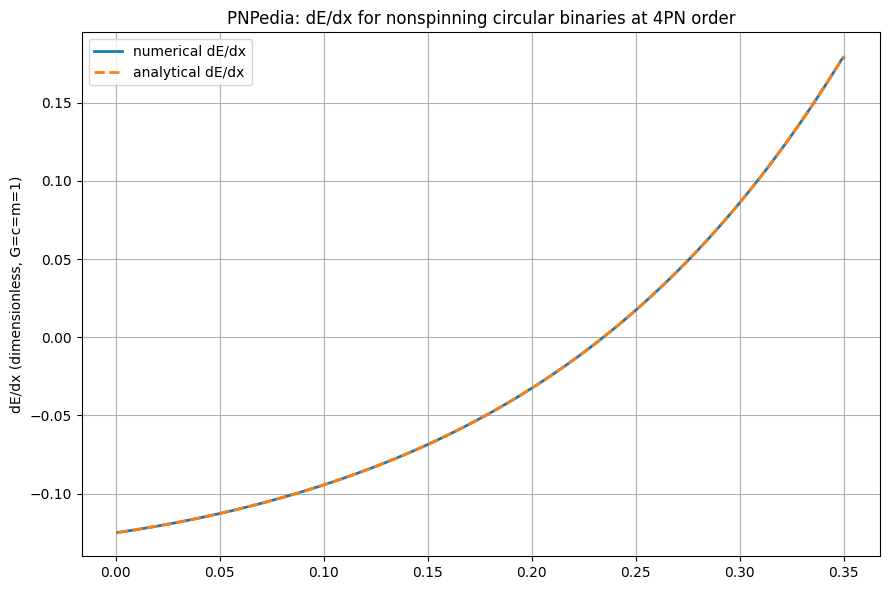

In [3]:
analytic_E = npd.get_pn_quantity('energy_circular_nonspinning_binding', '4')
analytic_E_dvt = analytic_E.derivative('x')

# plot the numerical derivative and the analytical one
numerical_dvt = np.gradient(analytic_E.to_function()[0](*[value_map[str(s)] for s in vrse]), x)
plt.figure(figsize=(9,6))
plt.plot(x, numerical_dvt, label='numerical dE/dx', lw=2)
plt.plot(x, analytic_E_dvt.to_function()[0](*[value_map[str(s)] for s in vrse]), label='analytical dE/dx', lw=2, ls='--')
plt.ylabel('dE/dx (dimensionless, G=c=m=1)')
plt.title('PNPedia: dE/dx for nonspinning circular binaries at 4PN order')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# AnalyticalExpression objects can be added, subtracted, multiplied, divided, etc.
# to create new derived quantities, exactly like standard sympy expressions.

from PyART.analytic import AnalyticExpression

simple_expression_1 = AnalyticExpression('x**2 + 3*x + 5 + 5*q', var=['x', 'q'])
simple_expression_2 = AnalyticExpression('2*x**3 - x + 1', var=['x'])

derived_expression = simple_expression_1 + simple_expression_2

print(derived_expression.expr)
print(derived_expression.truncate('x', 2).expr)  # truncate to x^2 order

5*q + 2*x**3 + x**2 + 2*x + 6
5*q + x**2 + 2*x + 6
